# Constants of motion

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lldddv2/relatipy/blob/main/docs/tutorials/07-constants-of-motion.ipynb)

A timelike geodesic of the Kerr spacetime has three constants of motion besides
the normalization of its four-velocity:

- the specific energy $E = -u_t$;
- the specific axial angular momentum $L_z = u_\phi$;
- the Carter constant $Q$ (not the alternative constant $K = Q + (L_z - aE)^2$).

RelatiPy returns them with `get_E`, `get_Lz` and `get_Q`, normalized with
$G = c = M = \mu = 1$, so they are plain numbers. This tutorial shows:

- how to read them from an orbit and from a solution;
- how to plot them along a solution;
- how to use them to measure the numerical drift of each integration method.

In [ ]:
%pip install -Uq relatipy

In [1]:
import numpy as np
from astropy import units as u
from astropy.constants import c

import relatipy as rp

## 1. Constants of an orbit

`Orbit.get_E`, `Orbit.get_Lz` and `Orbit.get_Q` evaluate the constants at the
orbit's current point, here its initial state. We use a bound, inclined orbit
around a rapidly spinning black hole, set up with the semi-latus rectum
$p = 6\,r_s$, the eccentricity $e = 0.3$ and the inclination parameter $x = 0.8$.
A bound orbit has $E < 1$.

In [2]:
bh = rp.Kerr(mass=1e6 * u.Msun, spin=0.9)
orbit = bh.orbit(p=(6 * bh.r_s).to(u.km), e=0.3, x=0.8)

print("E  =", orbit.get_E())
print("Lz =", orbit.get_Lz())
print("Q  =", orbit.get_Q())

E  = 0.96371682200246
Lz = 3.0369437348776414
Q  = 5.208729294503195


## 2. What the constants tell about the orbit

The signs and zeros of the constants follow the geometry of the orbit:

- an equatorial orbit ($x = \pm 1$) has $Q = 0$;
- a retrograde orbit ($x < 0$) has $L_z < 0$;
- with the same $p$ and $e$, the prograde and retrograde orbits have different
  energies around a spinning black hole.

In [3]:
for x in (1.0, 0.8, -0.8, -1.0):
    o = bh.orbit(p=(6 * bh.r_s).to(u.km), e=0.3, x=x)
    print(f"x = {x:+.1f}")
    print(f"  E  = {o.get_E():.6f}")
    print(f"  Lz = {o.get_Lz():+.6f}")
    print(f"  Q  = {o.get_Q():.6f}")

x = +1.0
  E  = 0.963410
  Lz = +3.753235
  Q  = 0.000000
x = +0.8
  E  = 0.963717
  Lz = +3.036944
  Q  = 5.208729
x = -0.8
  E  = 0.967444
  Lz = -3.421655
  Q  = 6.604270
x = -1.0
  E  = 0.968127
  Lz = -4.357759
  Q  = 0.000000


## 3. Constants along a solution

On a `Solution`, `get_E`, `get_Lz` and `get_Q` return one value per stored
sample, as read-only arrays aligned with `solution.tau`. The stored
four-velocities are not renormalized, so the arrays show the numerical drift of
the integration. Without `tau_eval` the solution stores every accepted native
step; we integrate $3000\,r_s/c$ of proper time, about 27 Keplerian periods of
the initial osculating ellipse (`orbit.get_keplerian_period()`).

In [4]:
T = (bh.r_s / c).to(u.s)
solution = orbit.solve(tau_span=(0 * u.s, 3000 * T))

E = solution.get_E()
print("samples:", E.shape)
print("E first:", E[0])
print("E last :", E[-1])
print("writeable:", E.flags.writeable)

samples: (1171,)
E first: 0.96371682200246
E last : 0.9637168225461128
writeable: False


## 4. Plotting the constants

`Solution.plot_constants` draws one panel per constant against coordinate time
`t` (the default) or proper time `tau`. When a series varies by less than
$10^{-4}$ of its magnitude, the panel shows $X - X_0$ and prints the first value
$X_0$ inside it, because tick labels could not resolve the values. Keywords
`E`, `Lz` and `Q` switch single panels off.

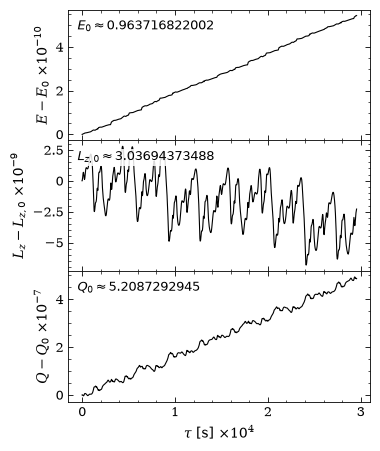

In [5]:
fig, axes = solution.plot_constants(time="tau")

With `drift=True` each panel shows the relative change
$(X - X_0)/|X_0|$ with respect to the first sample instead (or $X - X_0$ when
$|X_0| < 10^{-12}$, as for $Q$ of an equatorial orbit).

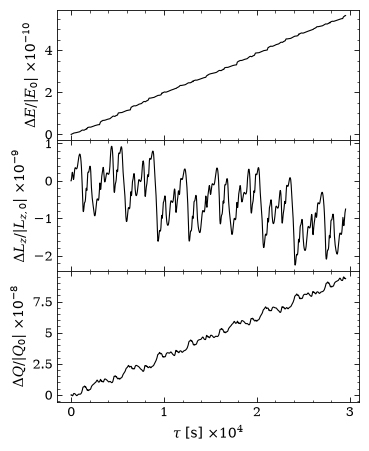

In [6]:
fig, axes = solution.plot_constants(time="tau", drift=True)

## 5. Drift of each method

The constants give a direct measure of integration quality. For each method we
integrate the same orbit with its automatic tolerances and print the largest
relative drift of every constant over the stored samples.

`"projection_radau"` projects each accepted step back to the initial norm, $E$,
$L_z$ and $Q$, so its drift stays at the level of floating-point rounding. The
other methods only control the local error, and their constants drift slowly.

In [7]:
def max_drift(values):
    return np.max(np.abs(values - values[0])) / abs(values[0])


solutions = {}
for method in ("radau", "dop853", "dp45", "projection_radau"):
    sol = orbit.solve(tau_span=(0 * u.s, 3000 * T), method=method)
    solutions[method] = sol
    print(method)
    print(f"  E  drift = {max_drift(sol.get_E()):.1e}")
    print(f"  Lz drift = {max_drift(sol.get_Lz()):.1e}")
    print(f"  Q  drift = {max_drift(sol.get_Q()):.1e}")

radau
  E  drift = 5.6e-10
  Lz drift = 2.2e-09
  Q  drift = 9.5e-08
dop853
  E  drift = 3.8e-12
  Lz drift = 1.8e-10
  Q  drift = 1.4e-09
dp45
  E  drift = 2.0e-10
  Lz drift = 6.4e-09
  Q  drift = 2.2e-09
projection_radau
  E  drift = 3.5e-16
  Lz drift = 4.4e-16
  Q  drift = 6.8e-16


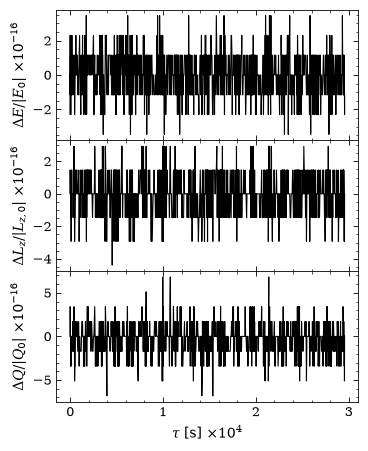

In [8]:
fig, axes = solutions["projection_radau"].plot_constants(time="tau", drift=True)

## 6. Accepted steps and `tau_eval` samples

The projection acts only on accepted native steps. Samples requested with
`tau_eval` fall between accepted steps and are interpolated, so they do not
inherit that guarantee: their constants show the interpolation error, which can
be much larger than the drift at the accepted steps. To check conservation, use
a solution without `tau_eval`.

In [9]:
taus = np.linspace(0, 3000, 800) * T
sampled = orbit.solve(tau_eval=taus, method="projection_radau")

print(f"accepted steps: E drift = {max_drift(solutions['projection_radau'].get_E()):.1e}")
print(f"tau_eval      : E drift = {max_drift(sampled.get_E()):.1e}")

accepted steps: E drift = 3.5e-16
tau_eval      : E drift = 1.0e-06


## Next steps

- [Integration controls](03-integration-controls.ipynb): methods, tolerances and outcomes.
- [Solutions and states](04-solutions-and-states.ipynb): views, indexing and interpolation.
- [Plotting](05-plotting.ipynb): the other figure methods.
- API reference: {doc}`../reference/geodesic` and {doc}`../reference/plotting`.